# Step 2 — Hierarchical Bayesian Accrual Quality Model

**Purpose:** Estimate firm-specific accounting noise $\sigma_i$ using a hierarchical Bayesian variant of the McNichols (2002) accrual model. The output — posterior distributions $p(\sigma_i \mid \text{data})$ — feeds into Step 3 (latent quality estimation).

**What this notebook does, step by step:**

1. **Load data** — Read per-firm CSVs from `acc_components_extracted` (balance sheet items) and `prof_components_extracted` (revenue), merge them by filename.
2. **Compute working capital accruals (WCA)** — Balance sheet approach: changes in operating current assets minus changes in operating current liabilities.
3. **Construct regressors** — CFO leads/lags, revenue growth, PPE — all scaled by lagged total assets.
4. **Estimate the HB model** — Firm-specific $\sigma_i$ pooled toward industry norms, with a rolling/expanding estimation window.
5. **Extract posteriors** — $p(\sigma_i \mid \text{data})$ for each firm-year, ready for Step 3.

**Key design choice:** For the portfolio formation year $t$, $\text{CFO}_{t+1}$ is treated as missing (NA). The model marginalises over the unknown future value — no look-ahead bias, no formula modification.

---
## 0. Setup and Imports

In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import pytensor.tensor as pt
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=FutureWarning)
np.random.seed(42)

print(f"PyMC version: {pm.__version__}")
print(f"ArviZ version: {az.__version__}")

PyMC version: 5.28.4
ArviZ version: 0.23.4


---
## 1. Load and Merge Data

We have two source folders:
- **`acc_components_extracted/`** — Balance sheet items per firm: ACT, CHE, LCT, STD, TXP, PPEGT, AT, OANCF
- **`prof_components_extracted/`** — Profitability items per firm, including REVT (revenue)

Files are matched by **filename** (e.g., `AFAGR.HE.csv` appears in both folders).

In [3]:
# ============================================================
# CONFIGURE PATHS — update these to match your directory layout
# ============================================================
ACC_DIR = os.path.join("..", "data", "acc_components_extracted")
PROF_DIR = os.path.join("..", "data", "prof_components_extracted")

# Verify folders exist
assert os.path.isdir(ACC_DIR), f"Cannot find {ACC_DIR} — notebook should be in Modelling/"
assert os.path.isdir(PROF_DIR), f"Cannot find {PROF_DIR} — notebook should be in Modelling/"

# --- Load accrual components ---
acc_frames = []
for fpath in sorted(glob.glob(os.path.join(ACC_DIR, "*.csv"))):
    df = pd.read_csv(fpath)
    df["_source_file"] = os.path.basename(fpath)  # keep filename for merge
    acc_frames.append(df)

acc_raw = pd.concat(acc_frames, ignore_index=True)
print(f"Loaded {len(acc_frames)} firm files from acc_components_extracted")
print(f"Total firm-year observations: {len(acc_raw)}")
print(f"Columns: {list(acc_raw.columns)}")

Loaded 633 firm files from acc_components_extracted
Total firm-year observations: 10354
Columns: ['Year', 'Ticker', 'CompanyName', 'Industry', 'Sector', 'ACT', 'CHE', 'LCT', 'STD', 'TXP', 'PPEGT', 'AT', 'OANCF', '_source_file']


In [4]:
# --- Load revenue from prof_components_extracted ---
# We only need REVT (revenue) from this folder.
# Merge key: filename + Year + Ticker

prof_frames = []
for fpath in sorted(glob.glob(os.path.join(PROF_DIR, "*.csv"))):
    df = pd.read_csv(fpath)
    df["_source_file"] = os.path.basename(fpath)
    # Only keep what we need
    cols_to_keep = [c for c in ["Year", "Ticker", "REVT", "_source_file"] if c in df.columns]
    prof_frames.append(df[cols_to_keep])

prof_raw = pd.concat(prof_frames, ignore_index=True)
print(f"Loaded {len(prof_frames)} firm files from prof_components_extracted")
print(f"Revenue observations: {len(prof_raw)}")

# Preview the revenue column
print(f"\nREVT non-null: {prof_raw['REVT'].notna().sum()} / {len(prof_raw)}")

Loaded 635 firm files from prof_components_extracted
Revenue observations: 10394

REVT non-null: 10394 / 10394


In [5]:
# --- Merge on filename + Year ---
# Filename is the company identifier across both folders
data = acc_raw.merge(
    prof_raw,
    on=["_source_file", "Year", "Ticker"],
    how="left"
)

print(f"Merged dataset: {len(data)} firm-year obs")
print(f"REVT coverage after merge: {data['REVT'].notna().sum()} / {len(data)}")
print(f"Unique firms: {data['Ticker'].nunique()}")
print(f"Year range: {data['Year'].min()} – {data['Year'].max()}")
data.head()

Merged dataset: 10361 firm-year obs
REVT coverage after merge: 10360 / 10361
Unique firms: 633
Year range: 1988 – 2024


,Year,Ticker,CompanyName,Industry,Sector,ACT,CHE,LCT,STD,TXP,PPEGT,AT,OANCF,_source_file,REVT
0,2017,20202.OL,2020 Bulkers Ltd,Freight & Logistics Services,Industrials,50.54,50.46,0.89,NaN,NaN,72.63,123.17,NaN,20202.OL.csv,0.00
1,2018,20202.OL,2020 Bulkers Ltd,Freight & Logistics Services,Industrials,3.34,2.44,4.12,NaN,0.32,590.75,594.09,-4.08,20202.OL.csv,0.00
2,2019,20202.OL,2020 Bulkers Ltd,Freight & Logistics Services,Industrials,201.03,176.45,112.36,71.11,NaN,1657.36,2485.17,44.87,20202.OL.csv,80.06
3,2020,20202.OL,2020 Bulkers Ltd,Freight & Logistics Services,Industrials,199.01,170.70,180.14,126.95,NaN,3193.55,3394.28,205.16,20202.OL.csv,460.19
4,2021,20202.OL,2020 Bulkers Ltd,Freight & Logistics Services,Industrials,248.35,211.36,187.58,130.34,NaN,3175.70,3439.90,717.66,20202.OL.csv,947.99


---
## 2. Compute Working Capital Accruals (WCA)

The dependent variable in the McNichols model. Constructed from balance sheet changes:

$$
\text{WCA}_{i,t} = (\Delta CA_{i,t} - \Delta Cash_{i,t}) - (\Delta CL_{i,t} - \Delta STD_{i,t} - \Delta TP_{i,t})
$$

**Why these exclusions?**
- **Cash (CHE):** Not an operating accrual — it's the residual of all cash flows.
- **Short-term debt (DLC/STD):** Financing decision, not operating.
- **Taxes payable (TXP):** Tax timing, not core operations.

Everything is scaled by lagged total assets $A_{i,t-1}$ to make firms comparable.

In [6]:
# Sort for correct within-firm differencing
data = data.sort_values(["Ticker", "Year"]).reset_index(drop=True)

# Fill missing STD and TXP with 0
# Rationale: if a firm reports no short-term debt or taxes payable,
# the balance is zero — not unknown. 
data["STD"] = data["STD"].fillna(0)
data["TXP"] = data["TXP"].fillna(0)

# --- Compute year-over-year changes within each firm ---
for col in ["ACT", "CHE", "LCT", "STD", "TXP"]:
    data[f"d_{col}"] = data.groupby("Ticker")[col].diff()

# --- Working capital accruals ---
data["WCA"] = (
    (data["d_ACT"] - data["d_CHE"])       # change in operating current assets
    - (data["d_LCT"] - data["d_STD"] - data["d_TXP"])  # change in operating current liabilities
)

# --- Lagged total assets (scaling denominator) ---
data["AT_lag"] = data.groupby("Ticker")["AT"].shift(1)

# --- Scaled WCA ---
data["WCA_scaled"] = data["WCA"] / data["AT_lag"]

print(f"WCA computed. Non-null scaled WCA: {data['WCA_scaled'].notna().sum()} / {len(data)}")
print(f"\nWCA_scaled summary statistics:")
data["WCA_scaled"].describe()

WCA computed. Non-null scaled WCA: 9563 / 10361

WCA_scaled summary statistics:


count    9563.000000
mean        0.096452
std         9.133556
min      -215.188014
25%        -0.029752
50%         0.003130
75%         0.041597
max       843.600000
Name: WCA_scaled, dtype: float64

---
## 3. Construct McNichols Regressors

The full McNichols (2002) specification:

$$
\frac{\text{WCA}_{i,t}}{A_{i,t-1}} = \alpha_i 
+ \beta_1 \frac{\text{CFO}_{i,t-1}}{A_{i,t-1}} 
+ \beta_2 \frac{\text{CFO}_{i,t}}{A_{i,t-1}} 
+ \beta_3 \frac{\text{CFO}_{i,t+1}}{A_{i,t-1}} 
+ \beta_4 \frac{\Delta\text{REV}_{i,t}}{A_{i,t-1}} 
+ \beta_5 \frac{\text{PPE}_{i,t}}{A_{i,t-1}} 
+ \varepsilon_{i,t}
$$

| Regressor | Source | Economic role |
|-----------|--------|---------------|
| $\text{CFO}_{t-1}$ | OANCF lagged | Accrual reversal — last year's accruals convert to cash |
| $\text{CFO}_{t}$ | OANCF current | Contemporaneous matching — accruals offset current cash flow |
| $\text{CFO}_{t+1}$ | OANCF lead | Realisation test — good accruals convert to future cash (NA for portfolio year) |
| $\Delta\text{REV}_{t}$ | REVT change | Growth control — high-growth firms naturally have large accruals |
| $\text{PPE}_{t}$ | PPEGT | Capital intensity — controls for systematic depreciation differences |

In [7]:
# --- CFO = OANCF (operating cash flow from statement of cash flows) ---
data["CFO"] = data["OANCF"]

# --- CFO leads and lags (within firm) ---
data["CFO_lag1"] = data.groupby("Ticker")["CFO"].shift(1)   # CFO_{t-1}
data["CFO_lead1"] = data.groupby("Ticker")["CFO"].shift(-1)  # CFO_{t+1}

# --- Revenue change ---
data["dREV"] = data.groupby("Ticker")["REVT"].diff()          # delta_REV_{t}

# --- Scale everything by lagged total assets ---
data["CFO_lag1_scaled"]  = data["CFO_lag1"]  / data["AT_lag"]
data["CFO_scaled"]       = data["CFO"]       / data["AT_lag"]
data["CFO_lead1_scaled"] = data["CFO_lead1"] / data["AT_lag"]
data["dREV_scaled"]      = data["dREV"]      / data["AT_lag"]
data["PPE_scaled"]       = data["PPEGT"]     / data["AT_lag"]

print("Regressor coverage (non-null counts):")
for col in ["WCA_scaled", "CFO_lag1_scaled", "CFO_scaled", "CFO_lead1_scaled", "dREV_scaled", "PPE_scaled"]:
    print(f"  {col:25s}: {data[col].notna().sum():>6d} / {len(data)}")

Regressor coverage (non-null counts):
  WCA_scaled               :   9563 / 10361
  CFO_lag1_scaled          :   9636 / 10361
  CFO_scaled               :   9667 / 10361
  CFO_lead1_scaled         :   9042 / 10361
  dREV_scaled              :   9709 / 10361
  PPE_scaled               :   9448 / 10361


---
## 4. Prepare Estimation Samples

### Rolling window with expanding startup

For each portfolio year $t$, the estimation window is:

| Portfolio year | Training data | Year $t$ treatment |
|---|---|---|
| 2008 (startup) | 2005–2007 (3 yr) | $\text{CFO}_{2009}$ = NA |
| 2009 | 2005–2008 (4 yr) | $\text{CFO}_{2010}$ = NA |
| 2010+ | $t{-}5$ to $t{-}1$ (5 yr rolling) | $\text{CFO}_{t+1}$ = NA |

**Training years** use full McNichols with $\text{CFO}_{t+1}$ observed.  
**Portfolio year $t$** uses the same formula but with $\text{CFO}_{t+1}$ = NA — the model marginalises over the missing value.

In [8]:
# --- Identify usable firm-years ---
# A row is usable for TRAINING if all regressors INCLUDING CFO_lead1 are non-null.
# A row is usable for PORTFOLIO YEAR if all regressors EXCEPT CFO_lead1 are non-null.

base_cols = ["WCA_scaled", "CFO_lag1_scaled", "CFO_scaled", "dREV_scaled", "PPE_scaled", "AT_lag"]

data["usable_train"] = data[base_cols + ["CFO_lead1_scaled"]].notna().all(axis=1)
data["usable_portfolio"] = data[base_cols].notna().all(axis=1)

print(f"Rows usable as training data (full McNichols): {data['usable_train'].sum()}")
print(f"Rows usable as portfolio year (CFO_t+1 = NA):  {data['usable_portfolio'].sum()}")

Rows usable as training data (full McNichols): 8709
Rows usable as portfolio year (CFO_t+1 = NA):  9334


In [9]:
# --- Assign industry codes for hierarchical pooling ---
# Using the 'Sector' column from the data (e.g., Materials, Information Technology)
# Each sector gets a numeric index for the HB model.

sector_map = {s: i for i, s in enumerate(sorted(data["Sector"].dropna().unique()))}
data["sector_idx"] = data["Sector"].map(sector_map)

print(f"Sectors found ({len(sector_map)}):")
for name, idx in sorted(sector_map.items(), key=lambda x: x[1]):
    n_firms = data.loc[data["sector_idx"] == idx, "Ticker"].nunique()
    print(f"  [{idx:2d}] {name:35s} — {n_firms} firms")

Sectors found (11):
  [ 0] Communication Services              — 31 firms
  [ 1] Consumer Discretionary              — 48 firms
  [ 2] Consumer Staples                    — 26 firms
  [ 3] Energy                              — 47 firms
  [ 4] Health Care                         — 80 firms
  [ 5] Industrials                         — 154 firms
  [ 6] Information Technology              — 78 firms
  [ 7] Materials                           — 46 firms
  [ 8] Other                               — 64 firms
  [ 9] Real Estate                         — 51 firms
  [10] Utilities                           — 8 firms


In [10]:
# --- Assign firm codes ---
firm_map = {t: i for i, t in enumerate(sorted(data["Ticker"].unique()))}
data["firm_idx"] = data["Ticker"].map(firm_map)

# --- Map each firm to its sector ---
firm_sector = (
    data.dropna(subset=["sector_idx"])
    .groupby("firm_idx")["sector_idx"]
    .first()
    .astype(int)
    .sort_index()
)

print(f"Total unique firms: {len(firm_map)}")
print(f"Firms with sector assignment: {len(firm_sector)}")

Total unique firms: 633
Firms with sector assignment: 633


In [11]:
def build_estimation_window(data, portfolio_year, min_train_years=3, max_train_years=5):
    """
    Build the estimation sample for a given portfolio year.
    
    Returns a DataFrame with columns:
      - All regressors (scaled)
      - firm_idx, sector_idx
      - is_portfolio_year: True for year t (CFO_t+1 will be masked)
    
    Window logic:
      - Training years: max(first_available, portfolio_year - max_train_years) to portfolio_year - 1
      - Startup: expands from min_train_years up to max_train_years
      - After startup: rolling max_train_years window
    """
    # Define year range
    train_start = portfolio_year - max_train_years
    train_end = portfolio_year - 1
    
    # Training data: full McNichols (need CFO_t+1)
    train_mask = (
        (data["Year"] >= train_start) & 
        (data["Year"] <= train_end) & 
        data["usable_train"]
    )
    
    # Portfolio year data: CFO_t+1 = NA
    portfolio_mask = (
        (data["Year"] == portfolio_year) & 
        data["usable_portfolio"]
    )
    
    train_df = data.loc[train_mask].copy()
    port_df = data.loc[portfolio_mask].copy()
    
    if len(train_df) == 0:
        return None  # Not enough training data
    
    # Check minimum training years
    n_train_years = train_df["Year"].nunique()
    if n_train_years < min_train_years:
        return None
    
    train_df["is_portfolio_year"] = False
    port_df["is_portfolio_year"] = True
    
    combined = pd.concat([train_df, port_df], ignore_index=True)
    
    return combined


# --- Determine which portfolio years are feasible ---
all_years = sorted(data["Year"].unique())
# We need at least 3 prior training years, so earliest portfolio year
# depends on when data starts. Let's check:
min_year = data.loc[data["usable_train"], "Year"].min()
earliest_portfolio = min_year + 3  # need 3 years of training
latest_portfolio = data["Year"].max()  # last year with data

feasible_years = [y for y in all_years if earliest_portfolio <= y <= latest_portfolio]

print(f"Earliest training year: {min_year}")
print(f"Feasible portfolio years: {feasible_years[0]} – {feasible_years[-1]} ({len(feasible_years)} years)")

# Preview one window
test_window = build_estimation_window(data, feasible_years[0])
if test_window is not None:
    print(f"\nExample window for portfolio year {feasible_years[0]}:")
    print(f"  Training obs: {(~test_window['is_portfolio_year']).sum()}")
    print(f"  Portfolio obs: {test_window['is_portfolio_year'].sum()}")
    print(f"  Training years: {sorted(test_window.loc[~test_window['is_portfolio_year'], 'Year'].unique())}")
    print(f"  Unique firms: {test_window['Ticker'].nunique()}")

Earliest training year: 1989
Feasible portfolio years: 1992 – 2024 (33 years)

Example window for portfolio year 1992:
  Training obs: 3
  Portfolio obs: 1
  Training years: [np.int64(1989), np.int64(1990), np.int64(1991)]
  Unique firms: 1


---
## 5. Winsorize Regressors

Extreme values in scaled variables can distort the model. We winsorize at the 1st/99th percentile cross-sectionally within each estimation window. This is applied *after* window construction so the thresholds are computed from the estimation sample, not the full dataset.

In [12]:
def winsorize(series, lower=0.01, upper=0.99):
    """Winsorize a series at the given percentiles."""
    lo = series.quantile(lower)
    hi = series.quantile(upper)
    return series.clip(lo, hi)

REGRESSOR_COLS = ["WCA_scaled", "CFO_lag1_scaled", "CFO_scaled", 
                  "CFO_lead1_scaled", "dREV_scaled", "PPE_scaled"]

---
## 6. The Hierarchical Bayesian Model

### Model structure

**Observation level:**
$$\text{WCA}_{i,t} \sim \text{Normal}(\mu_{i,t},\; \sigma_i^2)$$

$$\mu_{i,t} = \alpha_{j[i]} + \beta_1 \cdot \text{CFO}_{t-1} + \beta_2 \cdot \text{CFO}_t + \beta_3 \cdot \text{CFO}_{t+1} + \beta_4 \cdot \Delta\text{REV} + \beta_5 \cdot \text{PPE}$$

For portfolio year $t$: $\text{CFO}_{t+1}$ is NA — PyMC marginalises over it.

**Firm level:**
$$\sigma_i \sim \text{HalfNormal}(\sigma_{j[i]})$$
$$\alpha_i \sim \text{Normal}(\alpha_{j[i]},\; \tau^2)$$

**Industry (sector) level:**
$$\sigma_j \sim \text{HalfNormal}(\sigma_0)$$
$$\alpha_j \sim \text{Normal}(\mu_0,\; \omega^2)$$

**Market level (hyperpriors):**
$$\sigma_0 \sim \text{HalfNormal}(0.1)$$
$$\mu_0 \sim \text{Normal}(0, 1)$$
$$\tau, \omega \sim \text{HalfNormal}(0.1)$$

### Why HB instead of OLS?

- **Firm-specific $\sigma_i$**: OLS gives one $\sigma$ for all firms. HB lets each firm have its own noise level.
- **Partial pooling**: Firms with short history are pulled toward their sector norm — stable estimates even with 3 years of data.
- **Posterior distributions**: We get $p(\sigma_i \mid \text{data})$, not just a point estimate. This uncertainty propagates to Step 3.
- **Missing data handling**: PyMC can marginalise over the missing $\text{CFO}_{t+1}$ — no need to drop the term or impute.

In [13]:
def build_hb_accrual_model(window_df, firm_sector_map):
    """
    Build the hierarchical Bayesian accrual model for one estimation window.
    
    Parameters
    ----------
    window_df : DataFrame
        Output of build_estimation_window(). Contains training + portfolio year data.
    firm_sector_map : Series
        Maps firm_idx -> sector_idx (for the full dataset).
    
    Returns
    -------
    model : pm.Model
    trace_vars : dict with index mappings needed to extract results
    """
    
    # --- Winsorize within this window ---
    wdf = window_df.copy()
    for col in REGRESSOR_COLS:
        if col in wdf.columns and wdf[col].notna().any():
            wdf[col] = winsorize(wdf[col])
    
    # --- Re-index firms and sectors to be contiguous within this window ---
    window_firms = sorted(wdf["firm_idx"].unique())
    window_firm_remap = {old: new for new, old in enumerate(window_firms)}
    wdf["w_firm"] = wdf["firm_idx"].map(window_firm_remap)
    
    # Map each window-firm to its sector
    window_firm_to_sector = []
    for old_idx in window_firms:
        if old_idx in firm_sector_map.index:
            window_firm_to_sector.append(firm_sector_map[old_idx])
        else:
            window_firm_to_sector.append(0)  # fallback
    
    window_sectors = sorted(set(window_firm_to_sector))
    sector_remap = {old: new for new, old in enumerate(window_sectors)}
    window_firm_to_sector = [sector_remap[s] for s in window_firm_to_sector]
    
    N_firms = len(window_firms)
    N_sectors = len(window_sectors)
    firm_to_sector = np.array(window_firm_to_sector, dtype=int)
    
    # --- Separate training vs portfolio year ---
    is_train = ~wdf["is_portfolio_year"].values
    is_port = wdf["is_portfolio_year"].values
    
    # Extract arrays
    y = wdf["WCA_scaled"].values
    firm_idx_arr = wdf["w_firm"].values.astype(int)
    
    cfo_lag1 = wdf["CFO_lag1_scaled"].values
    cfo_curr = wdf["CFO_scaled"].values
    cfo_lead1 = wdf["CFO_lead1_scaled"].values.copy()  # NaN for portfolio year
    drev = wdf["dREV_scaled"].values
    ppe = wdf["PPE_scaled"].values
    
    # For training rows, CFO_lead1 is observed.
    # For portfolio rows, CFO_lead1 is NaN — we'll handle this with a mask.
    has_lead = ~np.isnan(cfo_lead1)
    # Replace NaN with 0 for the array (the model will use the imputed value instead)
    cfo_lead1_observed = np.where(has_lead, cfo_lead1, 0.0)
    
    N_obs = len(y)
    
    # --- Build PyMC model ---
    coords = {
        "firm": window_firms,
        "sector": window_sectors,
        "obs": np.arange(N_obs),
    }
    
    with pm.Model(coords=coords) as model:
        
        # ========== MARKET-LEVEL HYPERPRIORS ==========
        sigma_0 = pm.HalfNormal("sigma_0", sigma=0.1)       # global noise baseline
        mu_0    = pm.Normal("mu_0", mu=0, sigma=1)           # global intercept mean
        omega   = pm.HalfNormal("omega", sigma=0.1)          # sector intercept spread
        tau     = pm.HalfNormal("tau", sigma=0.1)            # firm intercept spread
        
        # ========== SECTOR-LEVEL ==========
        sigma_sector = pm.HalfNormal("sigma_sector", sigma=sigma_0, dims="sector")
        alpha_sector = pm.Normal("alpha_sector", mu=mu_0, sigma=omega, dims="sector")
        
        # ========== FIRM-LEVEL ==========
        sigma_firm = pm.HalfNormal(
            "sigma_firm", 
            sigma=sigma_sector[firm_to_sector],  # pooled toward sector
            dims="firm"
        )
        alpha_firm = pm.Normal(
            "alpha_firm", 
            mu=alpha_sector[firm_to_sector],      # pooled toward sector
            sigma=tau, 
            dims="firm"
        )
        
        # ========== REGRESSION COEFFICIENTS ==========
        # Shared across all firms (common slope parameters)
        beta1 = pm.Normal("beta_CFO_lag1", mu=0, sigma=1)   # CFO_{t-1}
        beta2 = pm.Normal("beta_CFO_curr", mu=0, sigma=1)   # CFO_t
        beta3 = pm.Normal("beta_CFO_lead1", mu=0, sigma=1)  # CFO_{t+1}
        beta4 = pm.Normal("beta_dREV", mu=0, sigma=1)       # delta_REV
        beta5 = pm.Normal("beta_PPE", mu=0, sigma=1)        # PPE
        
        # ========== HANDLE MISSING CFO_{t+1} ==========
        # For portfolio year observations, CFO_{t+1} is unknown.
        # We impute it from a prior centered on the firm's current CFO
        # (reasonable: cash flows are persistent).
        n_missing = int((~has_lead).sum())
        if n_missing > 0:
            # Prior for missing CFO_lead1: centered on 0 with moderate uncertainty
            # (data is already scaled by assets, so 0 is a reasonable center)
            cfo_lead1_missing = pm.Normal(
                "CFO_lead1_imputed", 
                mu=0, 
                sigma=0.2,  # moderately uncertain
                shape=n_missing
            )
            
            # Build the full CFO_lead1 vector:
            # observed values where available, imputed where missing
            cfo_lead1_full = pt.as_tensor_variable(cfo_lead1_observed.copy())
            # Replace missing positions with imputed values
            missing_indices = np.where(~has_lead)[0]
            cfo_lead1_full = pt.set_subtensor(
                cfo_lead1_full[missing_indices], 
                cfo_lead1_missing
            )
        else:
            cfo_lead1_full = pt.as_tensor_variable(cfo_lead1_observed)
        
        # ========== LINEAR PREDICTOR ==========
        mu = (
            alpha_firm[firm_idx_arr]
            + beta1 * cfo_lag1
            + beta2 * cfo_curr
            + beta3 * cfo_lead1_full
            + beta4 * drev
            + beta5 * ppe
        )
        
        # ========== LIKELIHOOD ==========
        # Each observation's noise comes from its firm's sigma
        obs_sigma = sigma_firm[firm_idx_arr]
        
        likelihood = pm.Normal(
            "WCA_obs", 
            mu=mu, 
            sigma=obs_sigma, 
            observed=y, 
            dims="obs"
        )
    
    # Return model + mappings for extracting results
    trace_info = {
        "window_firms": window_firms,         # original firm_idx values
        "window_firm_remap": window_firm_remap,
        "window_sectors": window_sectors,      # original sector_idx values
        "sector_remap": sector_remap,
        "firm_to_sector": firm_to_sector,
        "n_train": int(is_train.sum()),
        "n_portfolio": int(is_port.sum()),
        "n_missing_cfo": n_missing if n_missing > 0 else 0,
    }
    
    return model, trace_info

---
## 7. Estimation Loop

We loop over each portfolio year, build the estimation window, construct and sample the HB model, then store the posterior draws for $\sigma_i$.

**Sampling configuration:**
- NUTS sampler (PyMC default)
- 2000 posterior draws (after 1000 tuning steps)
- 2 chains (for convergence diagnostics)

**Note:** This is computationally intensive. For a first pass / debugging, you can limit to a subset of portfolio years or reduce the number of draws.

In [14]:
# ============================================================
# SAMPLING CONFIGURATION — adjust for speed vs quality tradeoff
# ============================================================
N_DRAWS = 2000     # posterior draws per chain
N_TUNE = 1000      # tuning steps (discarded)
N_CHAINS = 2       # number of MCMC chains
TARGET_ACCEPT = 0.9  # target acceptance rate (higher = more conservative)

# Year filter — only run portfolio years in this range
YEAR_START = 2018
YEAR_END = 2024

PORTFOLIO_YEARS_TO_RUN = [y for y in feasible_years if YEAR_START <= y <= YEAR_END]

# For debugging: set to a subset, e.g. PORTFOLIO_YEARS_TO_RUN[:2]
# PORTFOLIO_YEARS_TO_RUN = PORTFOLIO_YEARS_TO_RUN[:2]

print(f"Will estimate HB model for {len(PORTFOLIO_YEARS_TO_RUN)} portfolio years")
print(f"Years: {PORTFOLIO_YEARS_TO_RUN}")
print(f"Sampling: {N_DRAWS} draws × {N_CHAINS} chains, {N_TUNE} tune steps")

Will estimate HB model for 7 portfolio years
Years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Sampling: 2000 draws × 2 chains, 1000 tune steps


In [16]:
# ============================================================
# MAIN ESTIMATION LOOP
# ============================================================
all_results = {}  # portfolio_year -> {firm_idx: posterior_samples_of_sigma}

for port_year in PORTFOLIO_YEARS_TO_RUN:
    print(f"\n{'='*60}")
    print(f"Portfolio year: {port_year}")
    print(f"{'='*60}")
    
    # --- Build estimation window ---
    window_df = build_estimation_window(data, port_year)
    if window_df is None:
        print(f"  SKIPPED — insufficient training data")
        continue
    
    n_train = (~window_df["is_portfolio_year"]).sum()
    n_port = window_df["is_portfolio_year"].sum()
    n_firms = window_df["Ticker"].nunique()
    train_years = sorted(window_df.loc[~window_df["is_portfolio_year"], "Year"].unique())
    
    print(f"  Training years: {train_years} ({n_train} obs)")
    print(f"  Portfolio year:  {port_year} ({n_port} obs, CFO_{{t+1}} = NA)")
    print(f"  Firms in window: {n_firms}")
    
    # --- Build model ---
    try:
        model, trace_info = build_hb_accrual_model(window_df, firm_sector)
    except Exception as e:
        print(f"  ERROR building model: {e}")
        continue
    
    print(f"  Model built: {trace_info['n_train']} train + {trace_info['n_portfolio']} portfolio obs")
    print(f"  Missing CFO_lead1 values: {trace_info['n_missing_cfo']}")
    
    # --- Sample ---
    try:
        with model:
            trace = pm.sample(
                draws=N_DRAWS,
                tune=N_TUNE,
                chains=N_CHAINS,
                target_accept=TARGET_ACCEPT,
                random_seed=42 + port_year,
                return_inferencedata=True,
                progressbar=True,
            )
    except Exception as e:
        print(f"  ERROR sampling: {e}")
        continue
    
    # --- Extract sigma posteriors ---
    # sigma_firm has shape (chains, draws, n_firms_in_window)
    sigma_samples = trace.posterior["sigma_firm"].values  # (chains, draws, firms)
    sigma_samples = sigma_samples.reshape(-1, sigma_samples.shape[-1])  # (total_draws, firms)
    
    # Map back to original firm indices
    year_results = {}
    for w_idx, orig_firm_idx in enumerate(trace_info["window_firms"]):
        year_results[orig_firm_idx] = sigma_samples[:, w_idx]
    
    all_results[port_year] = year_results
    
    # --- Convergence diagnostics ---
    rhat = az.rhat(trace, var_names=["sigma_firm"])
    max_rhat = float(rhat["sigma_firm"].max())
    print(f"  Sampling complete. Max R-hat (sigma_firm): {max_rhat:.4f}")
    if max_rhat > 1.05:
        print(f"  ⚠️  WARNING: R-hat > 1.05 — chains may not have converged!")
    else:
        print(f"  ✓ Convergence looks good (R-hat < 1.05)")

print(f"\n\nDone! Estimated {len(all_results)} portfolio years.")


Portfolio year: 2018
  Training years: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017)] (2322 obs)
  Portfolio year:  2018 (530 obs, CFO_{t+1} = NA)
  Firms in window: 534
  Model built: 2322 train + 530 portfolio obs
  Missing CFO_lead1 values: 0


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [sigma_0, mu_0, omega, tau, sigma_sector, alpha_sector, sigma_firm, alpha_firm, beta_CFO_lag1, beta_CFO_curr, beta_CFO_lead1, beta_dREV, beta_PPE]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 62 seconds.
There were 480 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


  Sampling complete. Max R-hat (sigma_firm): 1.0220
  ✓ Convergence looks good (R-hat < 1.05)

Portfolio year: 2019
  Training years: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)] (2432 obs)
  Portfolio year:  2019 (557 obs, CFO_{t+1} = NA)
  Firms in window: 563
  Model built: 2432 train + 557 portfolio obs
  Missing CFO_lead1 values: 0


...

  Sampling complete. Max R-hat (sigma_firm): 1.2864
  ⚠️  WARNING: R-hat > 1.05 — chains may not have converged!

Portfolio year: 2024
  Training years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)] (2977 obs)
  Portfolio year:  2024 (621 obs, CFO_{t+1} = NA)
  Firms in window: 626
  Model built: 2977 train + 621 portfolio obs
  Missing CFO_lead1 values: 621


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [sigma_0, mu_0, omega, tau, sigma_sector, alpha_sector, sigma_firm, alpha_firm, beta_CFO_lag1, beta_CFO_curr, beta_CFO_lead1, beta_dREV, beta_PPE, CFO_lead1_imputed]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 78 seconds.
There were 149 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


  Sampling complete. Max R-hat (sigma_firm): 1.0699
  ⚠️  WARNING: R-hat > 1.05 — chains may not have converged!


Done! Estimated 7 portfolio years.


---
## 8. Extract and Store Results

For each firm-year, we now have the full posterior distribution $p(\sigma_i \mid \text{data})$.

**Two output formats:**
1. **Summary table:** Posterior mean, median, std, and 90% credible interval per firm-year. This is the "plug-in" version for Step 3.
2. **Full posterior samples:** All 2000+ draws per firm-year. This is the "correct" version for Step 3 (propagates estimation uncertainty).

In [18]:
# --- Build summary table ---
summary_rows = []

# Reverse firm map for lookup
firm_map_rev = {v: k for k, v in firm_map.items()}

for port_year, year_results in sorted(all_results.items()):
    for firm_idx, sigma_draws in year_results.items():
        ticker = firm_map_rev.get(firm_idx, f"firm_{firm_idx}")
        summary_rows.append({
            "Year": port_year,
            "Ticker": ticker,
            "firm_idx": firm_idx,
            "sigma_mean": np.mean(sigma_draws),
            "sigma_median": np.median(sigma_draws),
            "sigma_std": np.std(sigma_draws),
            "sigma_q05": np.percentile(sigma_draws, 5),
            "sigma_q95": np.percentile(sigma_draws, 95),
            "n_draws": len(sigma_draws),
        })

sigma_summary = pd.DataFrame(summary_rows)

print(f"Sigma summary table: {len(sigma_summary)} firm-year estimates")
print(f"Unique firms: {sigma_summary['Ticker'].nunique()}")
print(f"Year range: {sigma_summary['Year'].min()} – {sigma_summary['Year'].max()}")
print(f"\nPosterior mean sigma distribution:")
sigma_summary["sigma_mean"].describe()

Sigma summary table: 4164 firm-year estimates
Unique firms: 627
Year range: 2018 – 2024

Posterior mean sigma distribution:


count    4164.000000
mean        0.079939
std         0.059968
min         0.001768
25%         0.037864
50%         0.061319
75%         0.103279
max         0.349927
Name: sigma_mean, dtype: float64

In [ ]:
# --- Save summary ---
sigma_summary.to_csv("sigma_posteriors_summary.csv", index=False)
print("Saved: sigma_posteriors_summary.csv")

# --- Save full posterior samples (for propagation to Step 3) ---
# Format: one row per firm-year, columns = draw_0, draw_1, ..., draw_N
full_rows = []
for port_year, year_results in sorted(all_results.items()):
    for firm_idx, sigma_draws in year_results.items():
        ticker = firm_map_rev.get(firm_idx, f"firm_{firm_idx}")
        row = {"Year": port_year, "Ticker": ticker, "firm_idx": firm_idx}
        for i, d in enumerate(sigma_draws):
            row[f"draw_{i}"] = d
        full_rows.append(row)

sigma_full = pd.DataFrame(full_rows)
sigma_full.to_csv("sigma_posteriors_full.csv", index=False)
print(f"Saved: sigma_posteriors_full.csv ({sigma_full.shape[1] - 3} draws per firm-year)")

---
## 9. Diagnostics and Visualization

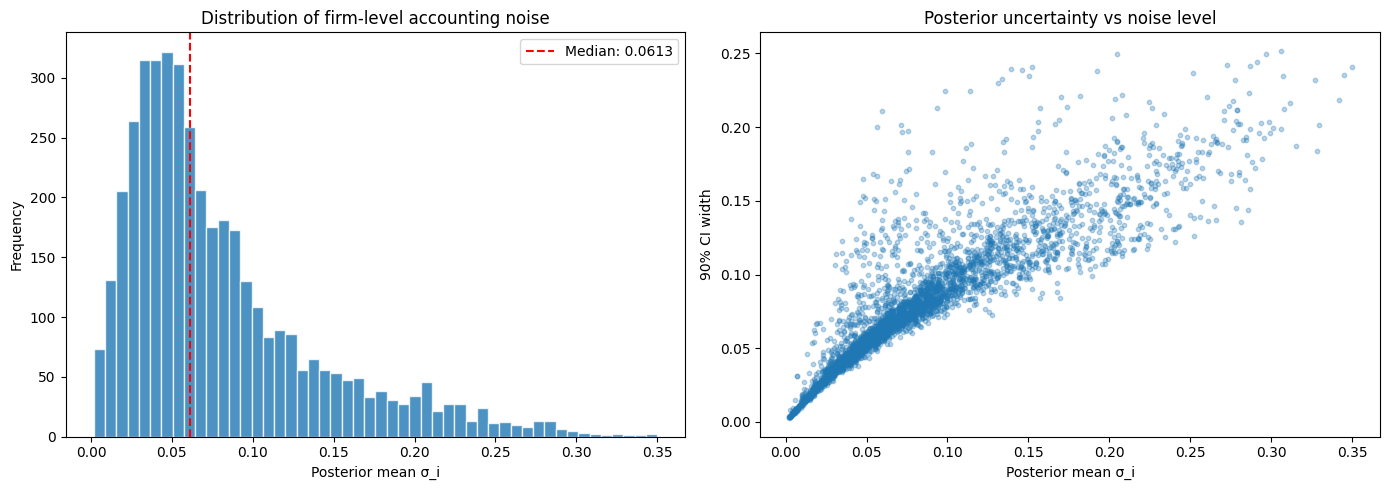

Saved: sigma_diagnostics.png


In [19]:
# --- Distribution of posterior mean sigma across all firm-years ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(sigma_summary["sigma_mean"], bins=50, edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Posterior mean σ_i")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of firm-level accounting noise")
axes[0].axvline(sigma_summary["sigma_mean"].median(), color="red", ls="--", 
                label=f"Median: {sigma_summary['sigma_mean'].median():.4f}")
axes[0].legend()

# Posterior uncertainty: width of 90% CI
sigma_summary["ci_width"] = sigma_summary["sigma_q95"] - sigma_summary["sigma_q05"]
axes[1].scatter(sigma_summary["sigma_mean"], sigma_summary["ci_width"], 
                alpha=0.3, s=10)
axes[1].set_xlabel("Posterior mean σ_i")
axes[1].set_ylabel("90% CI width")
axes[1].set_title("Posterior uncertainty vs noise level")

plt.tight_layout()
plt.savefig("sigma_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sigma_diagnostics.png")

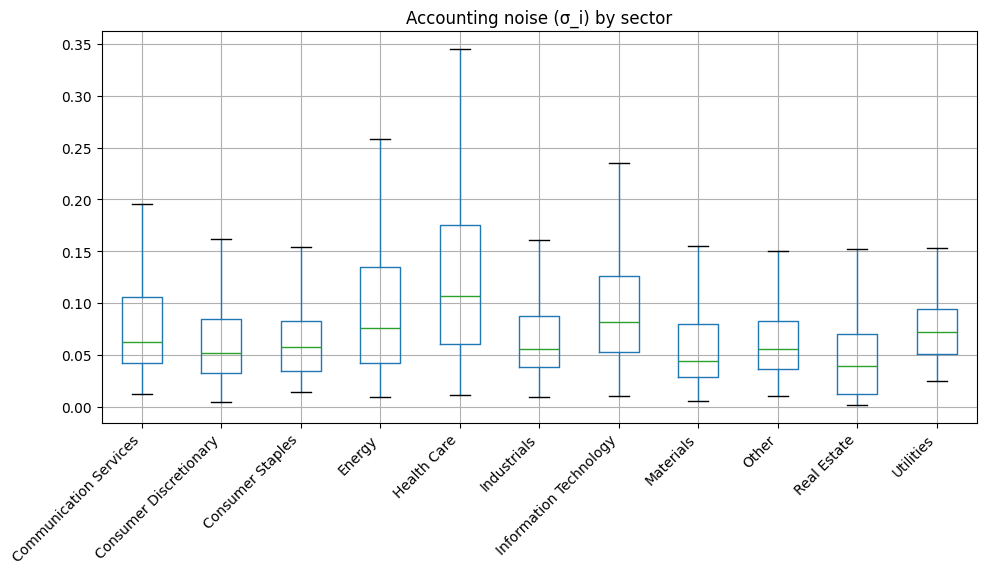


Median σ by sector:
Sector
Health Care               0.106835
Information Technology    0.081365
Energy                    0.075853
Utilities                 0.072162
Communication Services    0.062107
Consumer Staples          0.057259
Other                     0.056039
Industrials               0.055205
Consumer Discretionary    0.052191
Materials                 0.044028
Real Estate               0.038931


In [20]:
# --- Sigma by sector ---
# Merge sector info back
sector_info = data[["Ticker", "Sector"]].drop_duplicates(subset="Ticker")
sigma_with_sector = sigma_summary.merge(sector_info, on="Ticker", how="left")

sector_medians = (
    sigma_with_sector
    .groupby("Sector")["sigma_mean"]
    .median()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
sigma_with_sector.boxplot(
    column="sigma_mean", 
    by="Sector", 
    ax=ax,
    vert=True,
    showfliers=False
)
ax.set_title("Accounting noise (σ_i) by sector")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.suptitle("")  # remove auto-title from boxplot
plt.tight_layout()
plt.savefig("sigma_by_sector.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nMedian σ by sector:")
print(sector_medians.to_string())

In [ ]:
# --- Example: posterior distribution for a few firms in the latest year ---
latest_year = max(all_results.keys())
latest_results = all_results[latest_year]

# Pick 5 firms with different noise levels
latest_sigma_means = {k: np.mean(v) for k, v in latest_results.items()}
sorted_firms = sorted(latest_sigma_means.items(), key=lambda x: x[1])

# Select firms at 10th, 30th, 50th, 70th, 90th percentiles
n = len(sorted_firms)
example_firms = [sorted_firms[int(n * p)][0] for p in [0.1, 0.3, 0.5, 0.7, 0.9]]

fig, ax = plt.subplots(figsize=(12, 5))
for firm_idx in example_firms:
    draws = latest_results[firm_idx]
    ticker = firm_map_rev.get(firm_idx, f"firm_{firm_idx}")
    ax.hist(draws, bins=40, alpha=0.5, density=True, 
            label=f"{ticker} (mean={np.mean(draws):.4f})")

ax.set_xlabel("σ_i")
ax.set_ylabel("Posterior density")
ax.set_title(f"Example firm posteriors — portfolio year {latest_year}")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("sigma_posterior_examples.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 10. Shrinkage Visualization

One of the key advantages of HB over OLS: firms with short history or extreme values are "shrunk" toward their sector norm. Let's visualize this.

In [ ]:
# --- Compare HB posterior mean vs raw within-firm residual std ---
# (Raw std = what OLS would give, approximately)

# Compute raw RMSE per firm from the latest window
latest_window = build_estimation_window(data, latest_year)
if latest_window is not None:
    # Simple OLS residuals: WCA_scaled regressed on the available regressors
    from sklearn.linear_model import LinearRegression
    
    train_only = latest_window[~latest_window["is_portfolio_year"]].copy()
    # Winsorize
    for col in REGRESSOR_COLS:
        if col in train_only.columns and train_only[col].notna().any():
            train_only[col] = winsorize(train_only[col])
    
    train_complete = train_only.dropna(subset=REGRESSOR_COLS)
    
    X_cols = ["CFO_lag1_scaled", "CFO_scaled", "CFO_lead1_scaled", "dREV_scaled", "PPE_scaled"]
    X = train_complete[X_cols].values
    y_train = train_complete["WCA_scaled"].values
    
    ols = LinearRegression().fit(X, y_train)
    train_complete["resid"] = y_train - ols.predict(X)
    
    # RMSE per firm
    raw_rmse = train_complete.groupby("firm_idx")["resid"].apply(
        lambda x: np.sqrt(np.mean(x**2))
    ).to_dict()
    
    # Scatter: raw RMSE vs HB posterior mean
    common_firms = set(raw_rmse.keys()) & set(latest_results.keys())
    
    raw_vals = [raw_rmse[f] for f in common_firms]
    hb_vals = [np.mean(latest_results[f]) for f in common_firms]
    
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(raw_vals, hb_vals, alpha=0.4, s=20)
    max_val = max(max(raw_vals), max(hb_vals))
    ax.plot([0, max_val], [0, max_val], "r--", alpha=0.5, label="45° line (no shrinkage)")
    ax.set_xlabel("Raw OLS RMSE (no pooling)")
    ax.set_ylabel("HB posterior mean σ_i (with pooling)")
    ax.set_title(f"Shrinkage effect — portfolio year {latest_year}")
    ax.legend()
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.savefig("shrinkage_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    print("Points below the 45° line = firms whose noise was shrunk toward the sector mean.")
    print("Points above = firms whose raw RMSE underestimated their noise (pulled up by pooling).")

---
## Summary

### What this notebook produced

| Output file | Content | Used in |
|---|---|---|
| `sigma_posteriors_summary.csv` | Posterior mean, median, std, 90% CI per firm-year | Step 3 (plug-in version) |
| `sigma_posteriors_full.csv` | All 2000+ posterior draws per firm-year | Step 3 (full propagation) |

### Key methodological notes

1. **No look-ahead bias:** CFO_{t+1} is treated as NA for the portfolio year. The model marginalises over the missing value via Bayesian imputation.

2. **Hierarchical pooling:** Firms with short history or extreme accrual patterns are regularised toward their sector norm. This gives stable σ estimates even with 3 years of data.

3. **Uncertainty propagation:** The full posterior samples in `sigma_posteriors_full.csv` should be passed to Step 3 (quality model) to correctly propagate estimation uncertainty. Using only the posterior mean (plug-in) slightly underestimates posterior intervals in Step 3.

4. **Stationarity assumption:** σ_i is estimated from the training window and assumed stable at year t. This may fail for firms undergoing major structural changes (M&A, restructuring). This should be acknowledged in the thesis limitations section.

5. **Residual interpretation:** Because CFO_{t+1} is missing for the portfolio year, residuals capture both genuine estimation error AND legitimate forward-looking accruals. Both make the signal imprecise from the investor's perspective — both are relevant noise.